# USDA National Nutrient Database — exploratory analysis

Dataset: [demomaster/usda-national-nutrient-database](https://www.kaggle.com/datasets/demomaster/usda-national-nutrient-database).

Each row is a **legacy-style Standard Reference food entry** (not a recipe database or branded menu). Numeric fields are **as provided in this export** (per-serving style values as encoded in the source table—not necessarily per 100 g).

**CSV resolution (deterministic):** under `/kaggle/input`, `data/`, or a `kagglehub` download directory, pick the `.csv` whose header contains **all** `EXPECTED_COLS`; if several match, pick the **largest file by byte size**.

In [1]:
from __future__ import annotations
from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

DATASET_SLUG = "demomaster/usda-national-nutrient-database"
EXPECTED_COLS = [
    "ID",
    "Description",
    "Calories",
    "Protein",
    "TotalFat",
    "Carbohydrate",
    "Sodium",
    "SaturatedFat",
    "Cholesterol",
    "Sugar",
    "Calcium",
    "Iron",
    "Potassium",
    "VitaminC",
    "VitaminE",
    "VitaminD",
]
NUM_COLS = [c for c in EXPECTED_COLS if c != "Description"]


def _headers_match(path: Path) -> bool:
    peek = pd.read_csv(path, nrows=0)
    return set(EXPECTED_COLS) <= set(peek.columns)


def resolve_csv_path() -> Path:
    roots: list[Path] = []
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        roots.extend(sorted(kaggle_root.iterdir()))
    local_data = Path("data")
    if local_data.exists():
        roots.append(local_data)
    for root in roots:
        candidates = [p for p in root.rglob("*.csv") if p.is_file() and _headers_match(p)]
        if candidates:
            return max(candidates, key=lambda p: p.stat().st_size)
    hub = Path(kagglehub.dataset_download(DATASET_SLUG))
    candidates = [p for p in hub.rglob("*.csv") if p.is_file() and _headers_match(p)]
    assert candidates, f"no CSV under {hub} with columns {EXPECTED_COLS}"
    return max(candidates, key=lambda p: p.stat().st_size)


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
extra = [c for c in df.columns if c not in EXPECTED_COLS]
assert not extra, f"unexpected columns: {extra}"
assert 7000 <= len(df) <= 8000, f"unexpected row count: {len(df)}"

print(len(df), "rows ×", df.shape[1], "cols")


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CSV: /Users/nicapotato/.cache/kagglehub/datasets/demomaster/usda-national-nutrient-database/versions/1/USDA.csv
7058 rows × 16 cols


## Table overview and data quality

Reference profile (Kaggle / external tool): ~**7,058** rows; **Sugar** ~**27%** missing; **SaturatedFat** / **Cholesterol** ~**4%** missing; **Sodium** ~**1%** missing; core macros ~**1** row missing; **Description** ~**7,054** unique (~**4** duplicates).

In [2]:
display(df.sample(5, random_state=7))
display(df.dtypes)

miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
vq = pd.DataFrame({"missing": miss, "pct": miss_pct})
display(vq[vq["missing"] > 0])

dup_desc = df["Description"].duplicated(keep=False).sum()
print("duplicate Description rows (incl. groups):", int(dup_desc))
print("unique Description:", df["Description"].nunique())

,ID,Description,Calories,Protein,TotalFat,Carbohydrate,Sodium,SaturatedFat,Cholesterol,Sugar,Calcium,Iron,Potassium,VitaminC,VitaminE,VitaminD
4993,17249,"LAMB,DOM,SHLDR,ARM,LN&FAT,1/8""FAT,CHOIC,RSTD",267.0,22.93,18.75,0.00,65.0,8.040,91.0,NaN,17.0,2.05,262.0,0.0,NaN,NaN
3634,13438,"BEEF,RND,TOP RND,LN,0""FAT,SEL,CKD,BRSD",190.0,36.12,4.00,0.00,45.0,1.370,90.0,0.00,4.0,3.32,334.0,0.0,NaN,NaN
473,4705,"SALAD DRSNG,CAESAR,FAT-FREE",131.0,1.47,0.23,30.73,1265.0,0.096,1.0,8.82,33.0,0.29,48.0,0.1,0.02,0.0
1235,6580,"CAMPBELL SOUP COMPANY,CAMPBELL'S SEL SOUP,VEG ...",33.0,1.22,0.20,6.53,196.0,0.000,0.0,2.45,16.0,0.29,NaN,0.0,NaN,NaN
3277,11897,"YAM,CKD,BLD,DRND,OR BKD,W/SALT",114.0,1.49,0.14,26.99,244.0,0.029,0.0,0.49,14.0,0.52,670.0,12.1,0.34,0.0


ID                int64
Description         str
Calories        float64
Protein         float64
TotalFat        float64
Carbohydrate    float64
Sodium          float64
SaturatedFat    float64
Cholesterol     float64
Sugar           float64
Calcium         float64
Iron            float64
Potassium       float64
VitaminC        float64
VitaminE        float64
VitaminD        float64
dtype: object

,missing,pct
VitaminD,2834,40.15
VitaminE,2720,38.54
Sugar,1910,27.06
Potassium,409,5.79
VitaminC,332,4.70
SaturatedFat,301,4.26
Cholesterol,288,4.08
Calcium,136,1.93
Iron,123,1.74
Sodium,84,1.19


duplicate Description rows (incl. groups): 8
unique Description: 7054


## Univariate distributions

Macros and calories are right-skewed; **Sodium** has a long upper tail (condiments, brined items, salt), so we plot `log1p(Sodium)` as well.

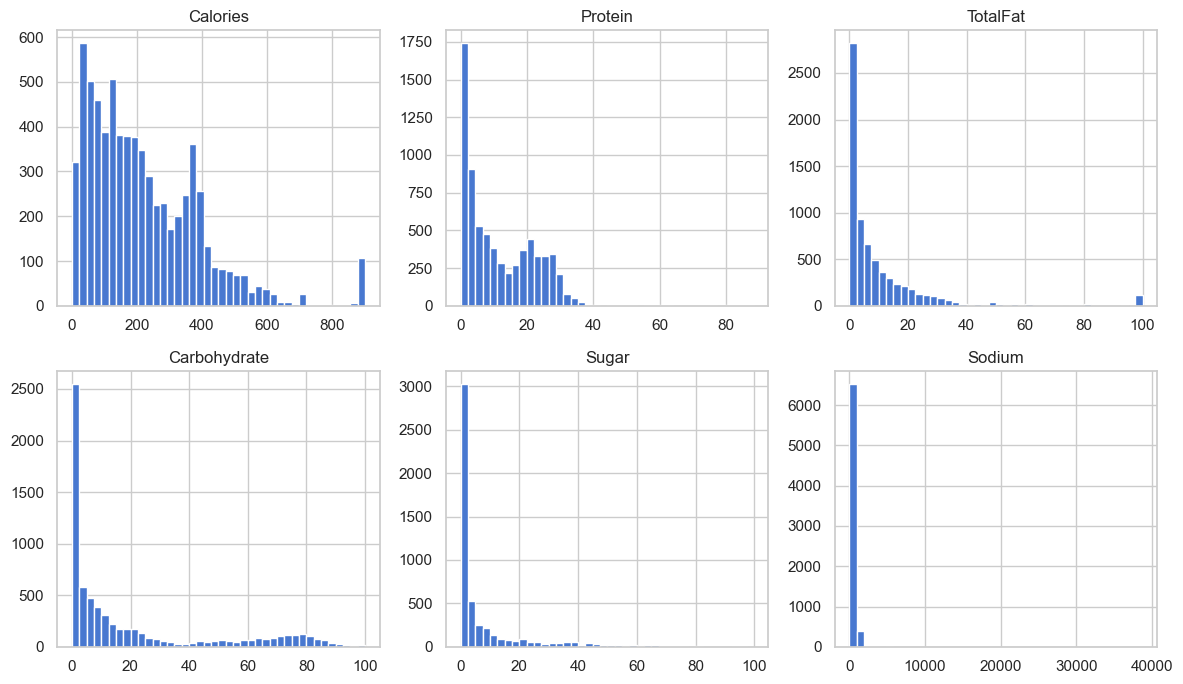

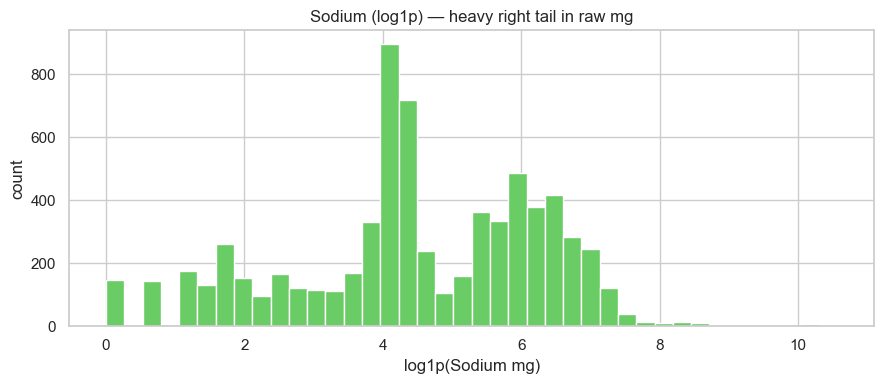

,Description,Sodium,Calories
264,"SALT,TABLE",38758.0,0.0
5323,"LEAVENING AGENTS,BAKING SODA",27360.0,0.0
5697,"DESSERTS,RENNIN,TABLETS,UNSWTND",26050.0,84.0
921,"SOUP,BF BROTH OR BOUILLON,PDR,DRY",26000.0,213.0
922,"SOUP,BEEF BROTH,CUBED,DRY",24000.0,170.0


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(
    axes,
    ["Calories", "Protein", "TotalFat", "Carbohydrate", "Sugar", "Sodium"],
):
    s = df[col].dropna()
    ax.hist(s, bins=40, color=sns.color_palette()[0], edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
s_na = df["Sodium"].dropna()
plt.hist(np.log1p(s_na), bins=40, color=sns.color_palette()[2], edgecolor="white")
plt.xlabel("log1p(Sodium mg)")
plt.ylabel("count")
plt.title("Sodium (log1p) — heavy right tail in raw mg")
plt.tight_layout()
plt.show()

top_na = df.nlargest(5, "Sodium")[["Description", "Sodium", "Calories"]]
display(top_na)

## Multivariate analysis

- **Correlation** on all numeric columns (pandas uses pairwise complete observations).
- **Scatter**: calories vs protein, marker size from total fat.
- **Category × Calories**: first comma-separated segment of `Description` (USDA hierarchy) — boxplot for top categories by frequency.

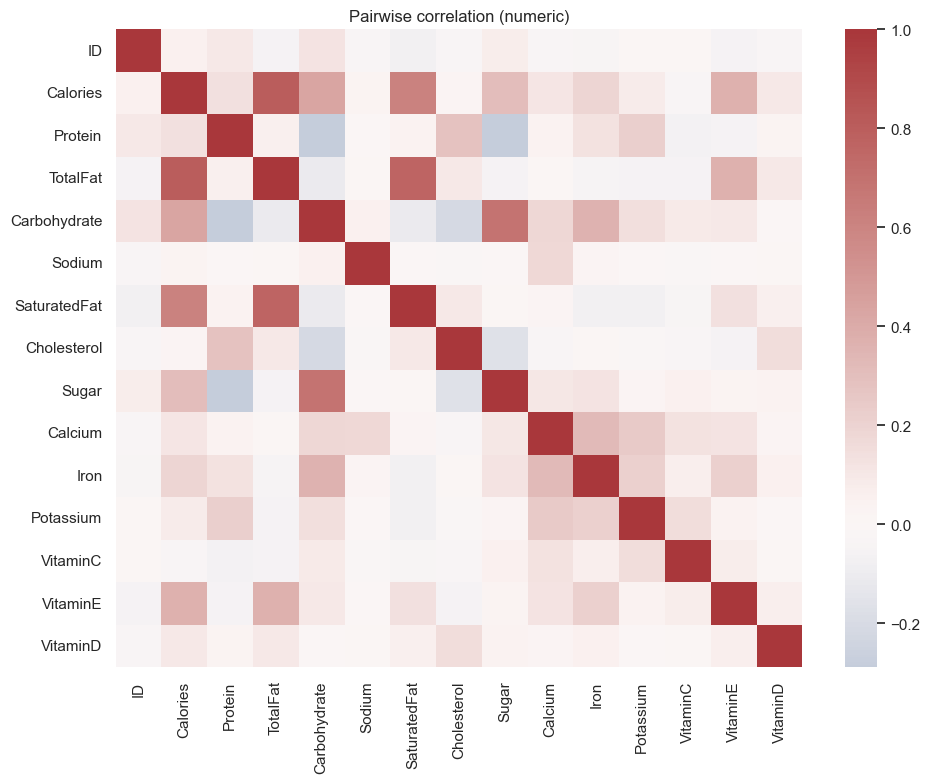

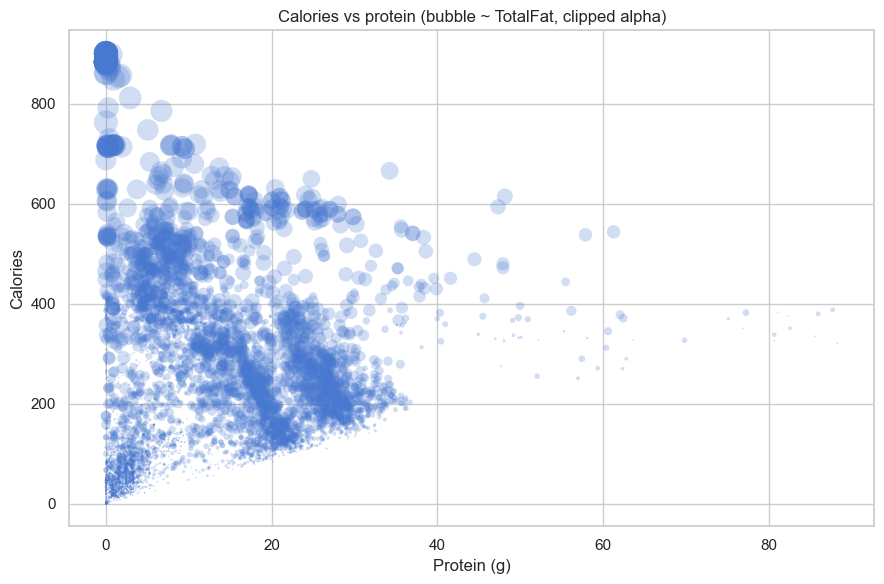

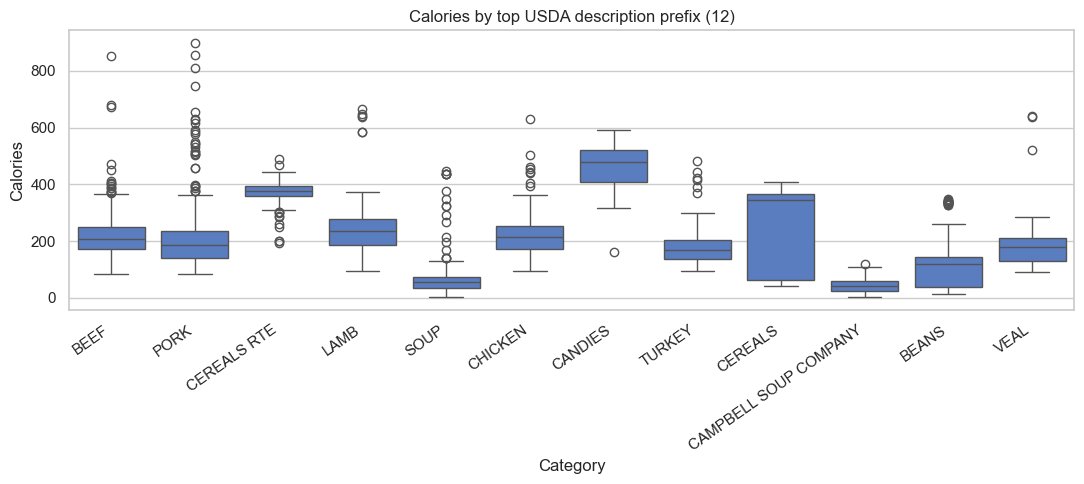

Subcategory,,FRSH,RAW,CND,FRZ,CKD,CURED,RND
Category,,,,,,,,
BEEF,0,0,0,0,0,0,11,110
PORK,0,191,0,0,0,0,111,0
CEREALS RTE,0,0,0,0,0,0,0,0
LAMB,0,0,0,0,0,0,0,0
SOUP,0,0,0,0,0,0,0,0
CHICKEN,0,0,0,1,0,0,0,0


In [4]:
corr = df[NUM_COLS].corr(min_periods=30)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="vlag", center=0)
plt.title("Pairwise correlation (numeric)")
plt.tight_layout()
plt.show()

sub = df.dropna(subset=["Calories", "Protein", "TotalFat"])
plt.figure(figsize=(9, 6))
sizes = np.clip(sub["TotalFat"], 0.5, None) * 3
plt.scatter(sub["Protein"], sub["Calories"], s=sizes, alpha=0.25, edgecolors="none")
plt.xlabel("Protein (g)")
plt.ylabel("Calories")
plt.title("Calories vs protein (bubble ~ TotalFat, clipped alpha)")
plt.tight_layout()
plt.show()

df = df.copy()
df["Category"] = (
    df["Description"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
    .str.upper()
)
top_cats = df["Category"].value_counts().head(12).index
box_df = df[df["Category"].isin(top_cats)]
plt.figure(figsize=(11, 5))
sns.boxplot(data=box_df, x="Category", y="Calories", order=top_cats)
plt.xticks(rotation=35, ha="right")
plt.title("Calories by top USDA description prefix (12)")
plt.tight_layout()
plt.show()

sec = (
    df["Description"]
    .astype(str)
    .str.split(",")
    .apply(lambda p: p[1].strip().upper() if len(p) > 1 else "")
)
df["Subcategory"] = sec
top_p = df["Category"].value_counts().head(6).index
top_s = df["Subcategory"].value_counts().head(8).index
ct = pd.crosstab(df["Category"], df["Subcategory"]).loc[top_p, top_s]
display(ct)

## Energy and macro density (tag breakdowns)

**Description tags:** same comma-separated USDA hierarchy as above — **`Category`** = first segment, **`Subcategory`** = second segment (use `(NONE)` when absent).

**Approximate calorie shares** use fixed Atwater factors: fat **9** kcal/g, carbohydrate **4** kcal/g, protein **4** kcal/g (denominator = reported **Calories**; shares can be noisy when calories are tiny or rounding differs from these factors).

**Plots:** the next cell renders **heatmaps**, **bar**, and **scatter** figures after the tables (the notebook enables the Matplotlib inline backend in the imports cell so figures show in Cursor/Jupyter).

**High-density slices** (for this export’s per-serving values):

- **Fat-dense:** at or above **75th percentile** for both **Calories** and **TotalFat**.
- **Carb-dense:** at or above **75th percentile** for both **Calories** and **Carbohydrate**.

Pivot tables summarize **median** and **count** of macros by tag; crosstabs relate tags to **calorie bins** and **fat quartiles**.


75p thresholds — Calories: 331, TotalFat: 12.70 g, Carbohydrate: 28.17 g
Fat-dense slice: 941 rows; carb-dense slice: 1267 rows


,Description,Calories,TotalFat,Carbohydrate,Protein,Category
288,"FAT,BEEF TALLOW",902.0,100.0,0.0,0.0,FAT
289,LARD,902.0,100.0,0.0,0.0,LARD
343,"FAT,MUTTON TALLOW",902.0,100.0,0.0,0.0,FAT
380,"FISH OIL,COD LIVER",902.0,100.0,0.0,0.0,FISH OIL
381,"FISH OIL,HERRING",902.0,100.0,0.0,0.0,FISH OIL
382,"FISH OIL,MENHADEN",902.0,100.0,0.0,0.0,FISH OIL
383,"FISH OIL,MENHADEN,FULLY HYDR",902.0,100.0,0.0,0.0,FISH OIL
384,"FISH OIL,SALMON",902.0,100.0,0.0,0.0,FISH OIL
385,"FISH OIL,SARDINE",902.0,100.0,0.0,0.0,FISH OIL
353,"FAT,CHICKEN",900.0,99.8,0.0,0.0,FAT


,Description,kcal_per_g_macro,Calories,TotalFat,Carbohydrate,Category
3892,"ALCOHOLIC BEV,DISTILLED,WHISKEY,86 PROOF",2500.000000,250.0,0.0,0.10,ALCOHOLIC BEV
4085,"ALCOHOLIC BEV,DISTILLED,ALL (GIN,RUM,VODKA,WHI...",2500.000000,250.0,0.0,0.10,ALCOHOLIC BEV
270,"VINEGAR,DISTILLED",450.000000,18.0,0.0,0.04,VINEGAR
268,"VANILLA EXTRACT,IMITN,ALCOHOL",96.341463,237.0,0.0,2.41,VANILLA EXTRACT
277,"VINEGAR,RED WINE",61.290323,19.0,0.0,0.27,VINEGAR
3927,"ALCOHOLIC BEV,WINE,TABLE,WHITE,PINOT BLANC",40.298507,81.0,0.0,1.94,ALCOHOLIC BEV
6953,"ALCOHOLIC BEV,WINE,LT",39.516129,49.0,0.0,1.17,ALCOHOLIC BEV
3911,"ALCOHOLIC BEV,WINE,TABLE,WHITE,PINOT GRIS (GRI...",38.967136,83.0,0.0,2.06,ALCOHOLIC BEV
3923,"ALCOHOLIC BEV,WINE,TABLE,WHITE,SAUVIGNON BLANC",38.207547,81.0,0.0,2.05,ALCOHOLIC BEV
3947,"ALCOHOLIC BEV,WINE,TABLE,WHITE,CHARDONNAY",37.668161,84.0,0.0,2.16,ALCOHOLIC BEV


Median macros by Category (top 15 by median calories)


,Calories,TotalFat,Carbohydrate,Protein
Category,,,,
LARD,902.0,100.00,0.0,0.0
FISH OIL,902.0,100.00,0.0,0.0
FAT,900.0,99.80,0.0,0.0
ANIMAL FAT,897.0,99.50,0.0,0.0
SHORTENING INDUSTRIAL,892.0,100.00,0.0,0.0
SHORTENING FRYING (HVY DUTY),892.0,100.00,0.0,0.0
MEAT DRIPPINGS (LARD,889.0,98.59,0.0,0.0
SHORTENING BREAD,884.0,100.00,0.0,0.0
OIL,884.0,100.00,0.0,0.0


...

Subcategory,MARS SNACKFOOD US,RIB,(NONE),INDUSTRIAL,FRSH,CURED,DRY RSTD,DOM,REG,DRIED,...,HEATH BITES,HAZELNUT,HALAVAH,GRUYERE,GRN GODDESS,GRAPESEED,GRANOLA BITES,GRANOLA BARS,GRANOLA,ZONE PERFECT CLASSIC CRUNCH BAR
Category,,,,,,,,,,,,,,,,,,,,,
CANDIES,26,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
OIL,0,0,0,23,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
BEEF,0,29,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
COOKIES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CHEESE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
SNACKS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
PORK,0,0,0,0,13,14,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SALAD DRSNG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


High carb-dense — Category × Subcategory (top categories by row total)


Subcategory,(NONE),5TH AVENUE CANDY BAR,ACID,AIR-POPPED,ALFREDO MIX,ALL FLAVORS XCPT CHOC,ALMOND,ALMOND JOY CANDY BAR,ANGELFOOD,ANIMAL CRACKERS (INCL ARROWROOT,...,WO/FAT,WO/SALT,YEAST-LEAVENED,YEL,YEL (NAVAJO),YELLOW,YORK BITES,YORK PEPPERMINT PATTIE,YUCCA (CASSAVA) CHIPS,ZONE PERFECT CLASSIC CRUNCH BAR
Category,,,,,,,,,,,,,,,,,,,,,
CEREALS RTE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CANDIES,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,1,0,0
CEREALS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SNACKS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
COOKIES,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
CRACKERS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WHEAT FLR,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PUDDINGS,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,Calories,Carbohydrate,TotalFat,pct_kcal_fat
Category,,,,
FISH OIL,902.0,0.0,100.00,99.778271
LARD,902.0,0.0,100.00,99.778271
FAT,900.0,0.0,99.80,99.800000
ANIMAL FAT,897.0,0.0,99.50,99.832776
SHORTENING FRYING (HVY DUTY),892.0,0.0,100.00,100.904977
SHORTENING INDUSTRIAL,892.0,0.0,100.00,100.904977
MEAT DRIPPINGS (LARD,889.0,0.0,98.59,99.809899
OIL,884.0,0.0,100.00,101.809955
SHORTENING,884.0,0.0,100.00,101.809955


,Calories,Carbohydrate,TotalFat,pct_kcal_carb
Category,,,,
CHOCOLATE,579.0,52.420,38.31,36.214162
DESSERT TOPPING,577.0,52.540,39.92,36.422877
CASHEW NUTS,577.0,31.425,47.06,21.772344
BEECHNUTS,576.0,33.500,50.00,23.263889
PISTACHIO NUTS,565.5,29.020,44.82,20.526436
PUFF PASTRY,554.5,45.400,38.30,32.750164
MCKEE BAKING,548.0,55.200,32.80,40.291971
CREAM SUBSTITUTE,545.0,54.880,35.48,40.278899
CHOCOLATE-FLAVORED HAZELNUT SPRD,541.0,62.160,29.73,45.959335


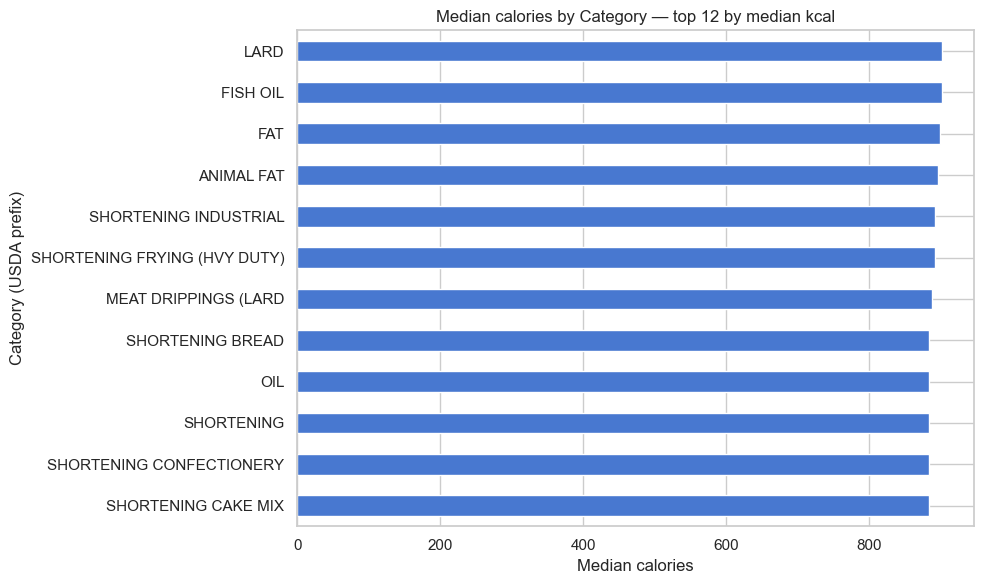

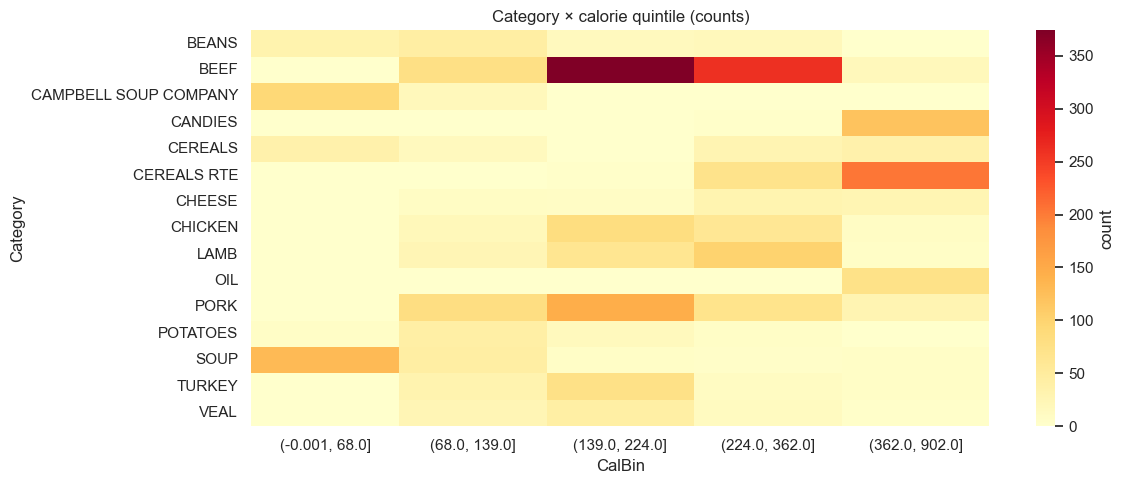

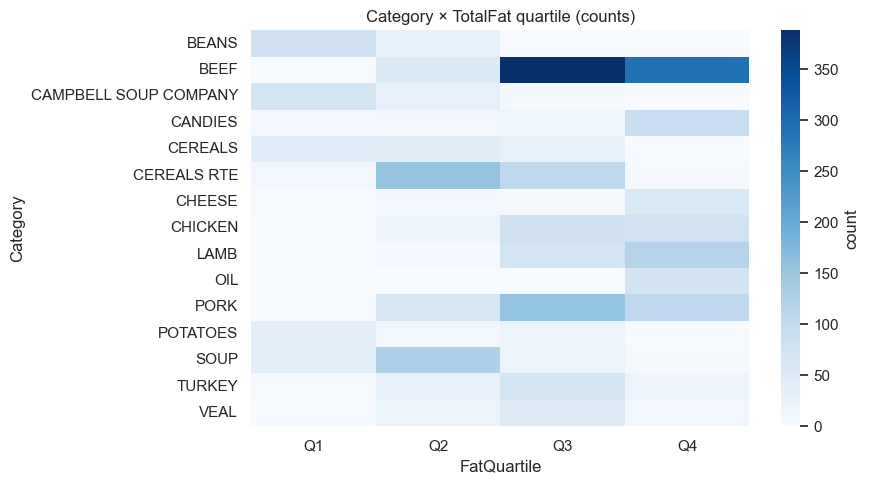

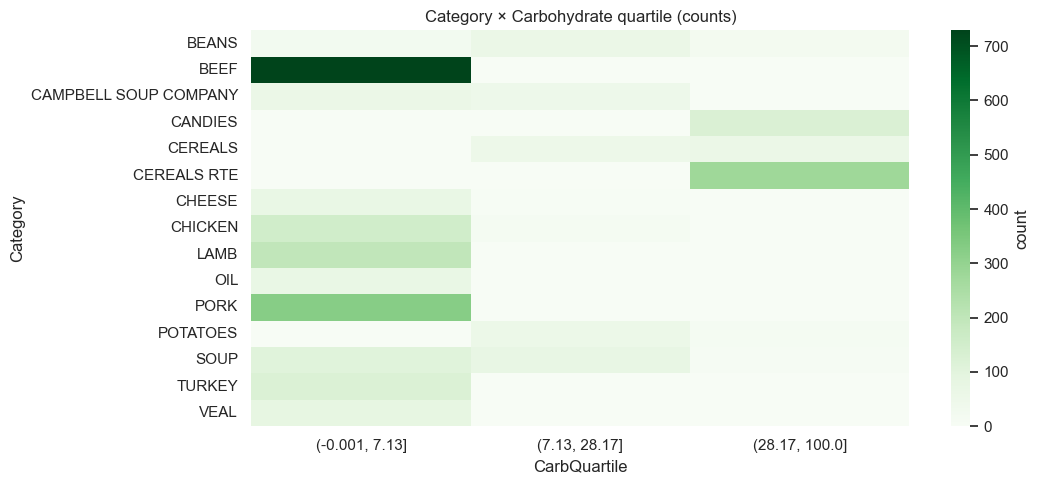

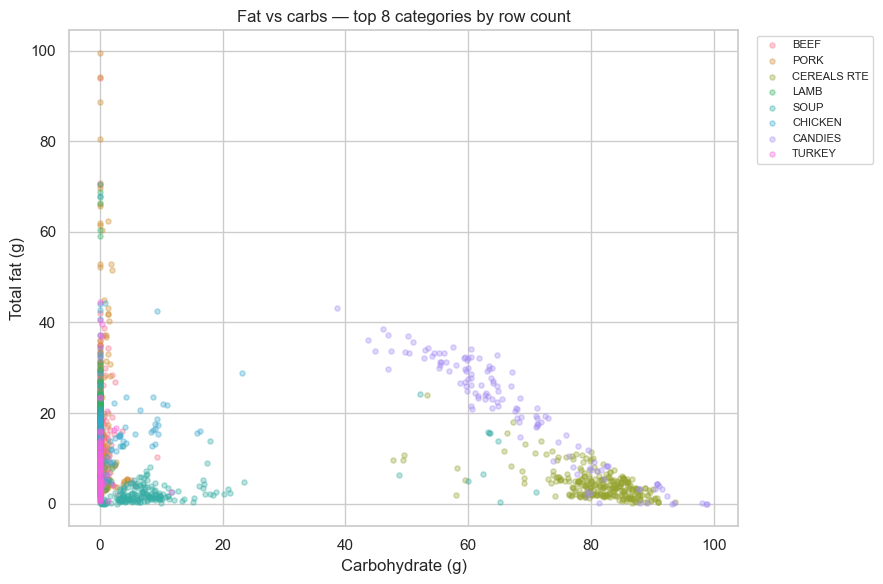

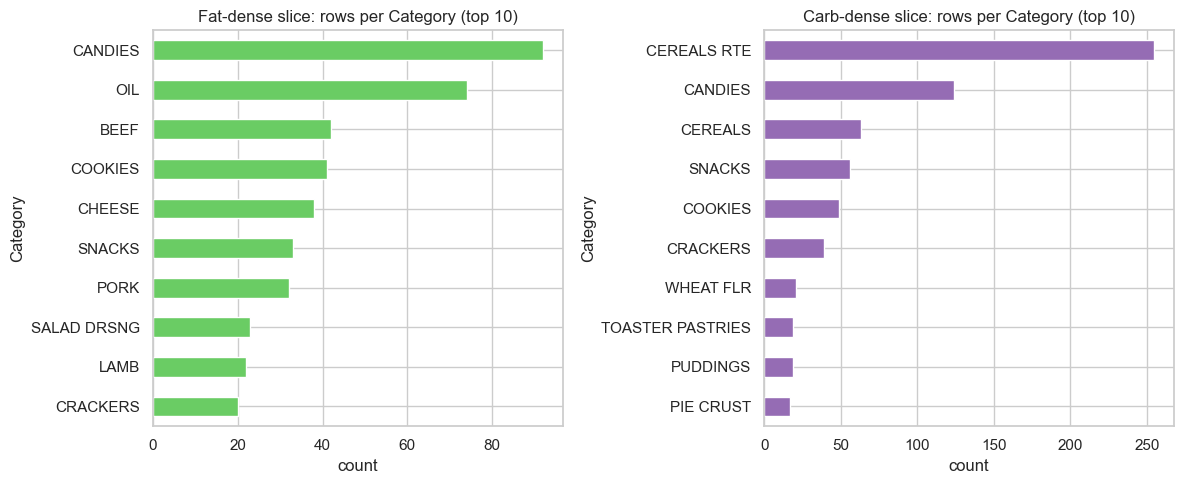

In [5]:
d = df.copy()
_parts = d["Description"].astype(str).str.split(",")
d["Category"] = _parts.str[0].str.strip().str.upper()
d["Subcategory"] = _parts.apply(
    lambda p: p[1].strip().upper() if len(p) > 1 else "(NONE)"
)

cal = d["Calories"].replace(0, np.nan)
d["pct_kcal_fat"] = (d["TotalFat"] * 9) / cal * 100
d["pct_kcal_carb"] = (d["Carbohydrate"] * 4) / cal * 100
d["pct_kcal_protein"] = (d["Protein"] * 4) / cal * 100

macro_sum = d["Protein"] + d["TotalFat"] + d["Carbohydrate"]
d["kcal_per_g_macro"] = d["Calories"] / macro_sum.replace(0, np.nan)

q75_cal = d["Calories"].quantile(0.75)
q75_fat = d["TotalFat"].quantile(0.75)
q75_carb = d["Carbohydrate"].quantile(0.75)
hi_fat_dense = d[(d["Calories"] >= q75_cal) & (d["TotalFat"] >= q75_fat)].copy()
hi_carb_dense = d[(d["Calories"] >= q75_cal) & (d["Carbohydrate"] >= q75_carb)].copy()

print(
    f"75p thresholds — Calories: {q75_cal:.0f}, TotalFat: {q75_fat:.2f} g, Carbohydrate: {q75_carb:.2f} g"
)
print(f"Fat-dense slice: {len(hi_fat_dense)} rows; carb-dense slice: {len(hi_carb_dense)} rows")

display(
    d.nlargest(15, "Calories")[
        ["Description", "Calories", "TotalFat", "Carbohydrate", "Protein", "Category"]
    ]
)
display(
    d.nlargest(15, "kcal_per_g_macro").dropna(subset=["kcal_per_g_macro"])[
        ["Description", "kcal_per_g_macro", "Calories", "TotalFat", "Carbohydrate", "Category"]
    ]
)

macro_cols = ["Calories", "TotalFat", "Carbohydrate", "Protein"]
pt_med_by_cat = (
    d.groupby("Category", observed=False)[macro_cols]
    .median()
    .sort_values("Calories", ascending=False)
)
print("Median macros by Category (top 15 by median calories)")
display(pt_med_by_cat.head(15))

top15_cat = d["Category"].value_counts().head(15).index
pt_top = (
    d[d["Category"].isin(top15_cat)]
    .groupby(["Category", "Subcategory"], observed=False)
    .agg(
        n=("ID", "count"),
        med_cal=("Calories", "median"),
        med_fat=("TotalFat", "median"),
        med_carb=("Carbohydrate", "median"),
        med_prot=("Protein", "median"),
        med_sugar=("Sugar", "median"),
    )
    .reset_index()
    .sort_values(["Category", "med_cal"], ascending=[True, False])
)
print("Pivot-style summary: n + median macros by Category × Subcategory (top 15 categories)")
display(pt_top.head(30))

sub_cal = d.loc[d["Calories"].notna()].copy()
sub_cal["CalBin"] = pd.qcut(sub_cal["Calories"], 5, duplicates="drop")
ct_cal = pd.crosstab(sub_cal["Category"], sub_cal["CalBin"])
ct_cal = ct_cal.loc[ct_cal.index.isin(top15_cat)]
print("Crosstab: row counts — Category × calorie quintile")
display(ct_cal)

sub_fat = d.loc[d["TotalFat"].notna()].copy()
sub_fat["FatQuartile"] = pd.qcut(
    sub_fat["TotalFat"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)
ct_fat = pd.crosstab(sub_fat["Category"], sub_fat["FatQuartile"])
ct_fat = ct_fat.loc[ct_fat.index.isin(top15_cat)]
print("Crosstab: Category × TotalFat quartile")
display(ct_fat)

sub_carb = d.loc[d["Carbohydrate"].notna()].copy()
sub_carb["CarbQuartile"] = pd.qcut(
    sub_carb["Carbohydrate"], 4, duplicates="drop"
)
ct_carb = pd.crosstab(sub_carb["Category"], sub_carb["CarbQuartile"])
ct_carb = ct_carb.loc[ct_carb.index.isin(top15_cat)]
print("Crosstab: Category × Carbohydrate quartile")
display(ct_carb)

ct_hf = pd.crosstab(hi_fat_dense["Category"], hi_fat_dense["Subcategory"])
cols_hf = ct_hf.sum(axis=0).sort_values(ascending=False).index
print("High fat-dense — Category × Subcategory (columns sorted by total count)")
display(ct_hf[cols_hf])

row_keep = ct_hf.sum(axis=1).nlargest(8).index
display(ct_hf.loc[row_keep, cols_hf])

ct_hi_carb = pd.crosstab(hi_carb_dense["Category"], hi_carb_dense["Subcategory"])
print("High carb-dense — Category × Subcategory (top categories by row total)")
display(ct_hi_carb.loc[ct_hi_carb.sum(axis=1).nlargest(8).index])

pivot_hi_fat = hi_fat_dense.pivot_table(
    index="Category",
    values=["Calories", "TotalFat", "Carbohydrate", "pct_kcal_fat"],
    aggfunc="median",
)
display(
    pivot_hi_fat.sort_values(["Calories", "TotalFat"], ascending=False).head(12)
)

pivot_hi_carb = hi_carb_dense.pivot_table(
    index="Category",
    values=["Calories", "TotalFat", "Carbohydrate", "pct_kcal_carb"],
    aggfunc="median",
)
display(
    pivot_hi_carb.sort_values(["Calories", "Carbohydrate"], ascending=False).head(12)
)

# --- Figures (heatmaps / bars; Cursor/Jupyter need the inline backend + plt.show)

plot_cats = pt_med_by_cat.head(12).index
fig, ax = plt.subplots(figsize=(10, 6))
pt_med_by_cat.loc[plot_cats, "Calories"].iloc[::-1].plot.barh(ax=ax, color=sns.color_palette()[0])
ax.set_xlabel("Median calories")
ax.set_ylabel("Category (USDA prefix)")
ax.set_title("Median calories by Category — top 12 by median kcal")
plt.tight_layout()
plt.show()

cal_hm = ct_cal.astype(float)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cal_hm, ax=ax, cmap="YlOrRd", cbar_kws={"label": "count"})
ax.set_title("Category × calorie quintile (counts)")
plt.tight_layout()
plt.show()

fat_hm = ct_fat.astype(float)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(fat_hm, ax=ax, cmap="Blues", cbar_kws={"label": "count"})
ax.set_title("Category × TotalFat quartile (counts)")
plt.tight_layout()
plt.show()

carb_hm = ct_carb.astype(float)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(carb_hm, ax=ax, cmap="Greens", cbar_kws={"label": "count"})
ax.set_title("Category × Carbohydrate quartile (counts)")
plt.tight_layout()
plt.show()

top8 = d["Category"].value_counts().head(8).index
sub_sc = d[d["Category"].isin(top8)].dropna(subset=["TotalFat", "Carbohydrate"])
fig, ax = plt.subplots(figsize=(9, 6))
pal = sns.color_palette("husl", n_colors=len(top8))
for i, cat in enumerate(top8):
    m = sub_sc["Category"] == cat
    ax.scatter(
        sub_sc.loc[m, "Carbohydrate"],
        sub_sc.loc[m, "TotalFat"],
        s=14,
        alpha=0.35,
        color=pal[i],
        label=cat[:22] + ("…" if len(cat) > 22 else ""),
    )
ax.set_xlabel("Carbohydrate (g)")
ax.set_ylabel("Total fat (g)")
ax.set_title("Fat vs carbs — top 8 categories by row count")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

vc_f = hi_fat_dense["Category"].value_counts().head(10)
vc_c = hi_carb_dense["Category"].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vc_f.iloc[::-1].plot.barh(ax=axes[0], color=sns.color_palette()[2])
axes[0].set_title("Fat-dense slice: rows per Category (top 10)")
axes[0].set_xlabel("count")
vc_c.iloc[::-1].plot.barh(ax=axes[1], color=sns.color_palette()[4])
axes[1].set_title("Carb-dense slice: rows per Category (top 10)")
axes[1].set_xlabel("count")
plt.tight_layout()
plt.show()




## Findings (agent-readable)

- **Shape**: ~7k legacy food rows with **16** nutrient fields in this export (core macros plus **Calcium**, **Iron**, **Potassium**, **VitaminC**, **VitaminE**, **VitaminD**).
- **Missingness**: **Sugar** is the main gap (~**27%** missing in this table); **SaturatedFat** and **Cholesterol** ~**4%**; **Sodium** ~**1%**; most other core fields have at most a handful of gaps—cross-check the missingness table above against your profiler.
- **IDs / labels**: `Description` is almost unique; a few duplicate labels appear—inspect those rows if merging on name.
- **Univariate**: Calories and macros span wide ranges (mixed foods); **Sodium** is strongly right-skewed with extreme mg values—always consider log scale or robust stats when summarizing salt.
- **Multivariate**: Correlations connect energy density with **fat**/**carb** patterns and electrolytes; the scatter shows higher protein often aligns with higher calories but slope varies by fat. **Category** (prefix) shifts the calorie distribution materially.
- **Energy / macro density**: Approximate **% kcal from fat (9)** / **carb (4)** / **protein (4)** and **kcal per g of summed macros** highlight the most energy-compact rows (often fats/oils). **Fat-dense** and **carb-dense** slices (calories and the respective macro both ≥ **75th percentile**) concentrate in different parts of the **Category × Subcategory** grid—see the crosstabs and median pivot tables in the density section; carbohydrate quartile bins use `qcut(..., duplicates="drop")` because many foods share **0 g** carb.
- **Limitations**: Serving basis is not normalized to 100 g here; compare foods using density-aware units if the question demands it. Pairwise correlations ignore interaction effects and non-linearities.

Notebook is self-contained for Kaggle (`/kaggle/input`) and local Mac runs via `kagglehub` (see `resolve_csv_path`).